# The ML Process, Data, and Features

**Working Example.** Copy this file, rename it (replace _case with your alias), and modify your copy.

See docs/your-files.md for more information. 

Do not edit this example.
It should stay runnable and available as a reference
until after your work has been assessed. 

Your notebook should reflect your name (or alias), the date, your dataset, and your target in the opening below.

- Author: Jaya
- Date: 2026-07
- Dataset: Seaborn Tips
- Target: tip

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M2: Instructional Approach

Module 1 provided vocabulary and how to characterize an ML problem.

Module 2 presents the early stages of the process: assessing data and building features. 

Module 3 will begin the actual model-building.

## M2: Features

In this project, we construct **features** and report how they look. 

We learn how to decide whether a constructed feature is *useful* or *leakage*.

## Overview

This project applies the M2 process to a new dataset and domain: Seaborn's `tips` dataset,
which records restaurant bills, tips, and party details (a service-industry problem,
distinct from the biological penguins example).

We choose to predict the target `tip`, the dollar amount left by the party.
This target is a **numeric** variable (rather than a discrete category), so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

A restaurant or delivery platform could use a model like this to estimate expected tip
amounts for staffing, forecasting, or driver-pay estimates.

## A. Prepare the Project Environment (.venv/)

- Open **only one project in VS Code at a time**.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## M2. The Machine Learning Process

A typical ML project moves through stages. 
Earlier stages decide how well the later ones can possibly do.

Stages:

1. M1: **Frame** the question (what is the target; is ML a good tool).
2. M1: **Load** the data.
3. M2: **Assess** the data - is it useful, complete, representative?
4. M2:**Construct features** - shape the inputs the model will learn from. 
5. M3+: **Model** - fit an estimator. 
6. M3+: **Evaluate** - assess performance accurately.
7. M3+: **Use / serve** the model.

**Identifying useful data** means asking, before modeling: 

does this column carry information about the target, 
is it populated, 
and will it actually be available when a prediction is needed? 

A column that is mostly missing, or that is **only known after the outcome**, is not useful. 
This second case is called **leakage**.

**Constructing features** means deriving new inputs 
from existing columns (e.g., ratios, sums, bins, flags) 
that make the signal easier for a model to use. 

The danger is building a feature out of the target itself, 
which leaks the answer.

## Section 1. Project Setup and Imports

In [11]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M02", level="DEBUG")
log_header(LOG, "M02")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-13 01:45:37 | INFO | M02 | === RUN START ===
2026-07-13 01:45:37 | INFO | M02 | project=M02
2026-07-13 01:45:37 | INFO | M02 | repo_dir=ml-02-features
2026-07-13 01:45:37 | INFO | M02 | python=3.14.6
2026-07-13 01:45:37 | INFO | M02 | os=Darwin 23.6.0
2026-07-13 01:45:37 | INFO | M02 | shell=zsh
2026-07-13 01:45:37 | INFO | M02 | cwd=notebooks
2026-07-13 01:45:37 | INFO | M02 | github_actions=False
2026-07-13 01:45:37 | INFO | M02 | Confirming installation:
2026-07-13 01:45:37 | INFO | M02 |   python:       3.14.6
2026-07-13 01:45:37 | INFO | M02 |   pandas:       3.0.3
2026-07-13 01:45:37 | INFO | M02 |   numpy:        2.5.1
2026-07-13 01:45:37 | INFO | M02 |   scikit-learn: 1.9.0
2026-07-13 01:45:37 | INFO | M02 |   seaborn:      0.13.2
2026-07-13 01:45:37 | INFO | M02 |   matplotlib:   3.11.0


## Section 2. Load the Data

In [12]:
# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: Applying the M2 process to a new dataset/domain: restaurant tips.
DATASET_NAME: Final[str] = "tips"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

2026-07-13 01:45:37 | INFO | M02 | Loading dataset: tips
2026-07-13 01:45:37 | INFO | M02 | Loaded: 244 rows (instances), 7 columns


## Section 3. Assess the Data

A column is useful only if it carries information about the target and will be
available at prediction time. The code below reports completeness and dtype
for each column; you decide which columns to keep, drop, or treat with suspicion.

In [13]:
# === Section 3. Assess the Data ===


INTENDED_TARGET: Final[str] = "tip"
LOG.info(f"The intended target is '{INTENDED_TARGET}'.")
LOG.info("Any feature derived FROM the target would leak the answer. Avoid those.")


LOG.info("Per-column completeness and type:")

n_rows: int = df.shape[0]

for col in df.columns:
    missing: int = int(df[col].isna().sum())
    pct_present: float = 100.0 * (n_rows - missing) / n_rows
    LOG.info(
        f"  {col:20s} {str(df[col].dtype):10s} present={pct_present:5.1f}%  missing={missing}"
    )

numeric_cols: list[str] = df.select_dtypes(include="number").columns.tolist()
LOG.info("Numeric summary (for spread / outliers):")
LOG.debug(f"\n{df[numeric_cols].describe()}")

2026-07-13 01:45:37 | INFO | M02 | The intended target is 'tip'.
2026-07-13 01:45:37 | INFO | M02 | Any feature derived FROM the target would leak the answer. Avoid those.
2026-07-13 01:45:37 | INFO | M02 | Per-column completeness and type:
2026-07-13 01:45:37 | INFO | M02 |   total_bill           float64    present=100.0%  missing=0
2026-07-13 01:45:37 | INFO | M02 |   tip                  float64    present=100.0%  missing=0
2026-07-13 01:45:37 | INFO | M02 |   sex                  category   present=100.0%  missing=0
2026-07-13 01:45:37 | INFO | M02 |   smoker               category   present=100.0%  missing=0
2026-07-13 01:45:37 | INFO | M02 |   day                  category   present=100.0%  missing=0
2026-07-13 01:45:37 | INFO | M02 |   time                 category   present=100.0%  missing=0
2026-07-13 01:45:37 | INFO | M02 |   size                 int64      present=100.0%  missing=0
2026-07-13 01:45:37 | INFO | M02 | Numeric summary (for spread / outliers):
2026-07-13 01:45:3

## Section 4. Construct Features

This example builds features from `total_bill`, `size`, and `day` —
a per-person bill amount, a weekend flag, and a party-size category.
None of these are derived from `tip` (the target).

2026-07-13 01:45:37 | INFO | M02 | Constructing features (vectorized, none are derived from the target)
2026-07-13 01:45:37 | INFO | M02 | Added features: ['bill_per_person', 'is_weekend', 'party_size_class']
2026-07-13 01:45:37 | DEBUG | M02 | Sample of constructed features:
2026-07-13 01:45:37 | DEBUG | M02 | 
   total_bill  size  bill_per_person  is_weekend party_size_class
0       16.99     2         8.495000        True            small
1       10.34     3         3.446667        True           medium
2       21.01     3         7.003333        True           medium
3       23.68     2        11.840000        True            small
4       24.59     4         6.147500        True           medium


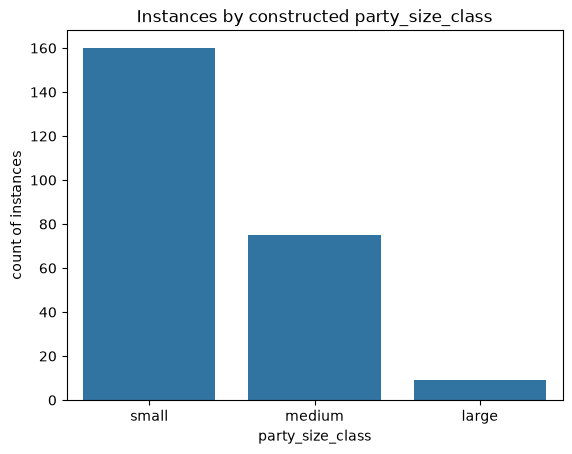

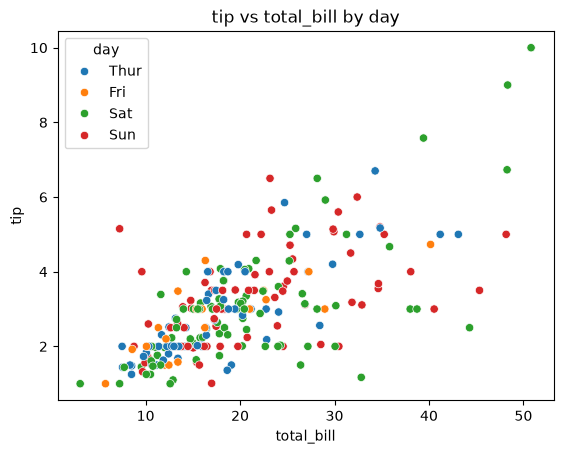

In [14]:
# === Section 4. Construct Features ===

LOG.info("Constructing features (vectorized, none are derived from the target)")

# Work on a copy so the original stays unchanged.
# Follow current pandas idiom:
# assign explicitly; avoid chained inplace, which silently does nothing
df_feat: pd.DataFrame = df.copy()

df_feat["bill_per_person"] = df_feat["total_bill"] / df_feat["size"]
df_feat["is_weekend"] = df_feat["day"].isin(["Sat", "Sun"])

# A categorical feature via binning. Bins are an ANALYST CHOICE.
df_feat["party_size_class"] = pd.cut(
    df_feat["size"],
    bins=[0, 2, 4, np.inf],
    labels=["small", "medium", "large"],
)

new_cols: list[str] = ["bill_per_person", "is_weekend", "party_size_class"]

LOG.info(f"Added features: {new_cols}")

LOG.debug("Sample of constructed features:")
LOG.debug(f"\n{df_feat[['total_bill', 'size', *new_cols]].head()}")

# Show the new categorical feature.
# Visualize in every project.

plt.figure()
sns.countplot(data=df_feat, x="party_size_class")
plt.title("Instances by constructed party_size_class")
plt.xlabel("party_size_class")
plt.ylabel("count of instances")
plt.show()

# total_bill looks strongly related to tip
plt.figure()
sns.scatterplot(data=df_feat, x="total_bill", y=INTENDED_TARGET, hue="day")
plt.title(f"{INTENDED_TARGET} vs total_bill by day")
plt.xlabel("total_bill")
plt.ylabel(INTENDED_TARGET)
plt.show()

## Section 5. Summary and Next Steps

In [15]:
# === Python Summary ===


"""Record where we are in the process and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:          {DATASET_NAME}")
LOG.info(f"Original columns: {df.shape[1]}")
LOG.info(f"After features:   {df_feat.shape[1]}")
LOG.info(f"Intended target:  {INTENDED_TARGET}")
LOG.info("========================")

2026-07-13 01:45:37 | INFO | M02 | ========================
2026-07-13 01:45:37 | INFO | M02 | SUMMARY
2026-07-13 01:45:37 | INFO | M02 | ========================
2026-07-13 01:45:37 | INFO | M02 | Dataset:          tips
2026-07-13 01:45:37 | INFO | M02 | Original columns: 7
2026-07-13 01:45:37 | INFO | M02 | After features:   10
2026-07-13 01:45:37 | INFO | M02 | Intended target:  tip
2026-07-13 01:45:37 | INFO | M02 | ========================
